In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import pickle

In [ ]:
with open("..\\Dataset\\NYC_DWT_Analysis\\viol_analysis_results.pkl", 'rb') as f:
    viol_info = pickle.load(f)

with open("..\\Dataset\\NYC_DWT_Analysis\\lag_analysis_results.pkl", 'rb') as f:
    lag_info = pickle.load(f)

In [6]:
def stationarity(series, name):
    s = series.dropna()
    
    # Using Augmented Dickey-Fuller and KPSS
    _, adf_p, *_ = adfuller(s)
    _, kpss_p, *_ = kpss(s, regression='c', nlags='auto')

    if adf_p < 0.05 and kpss_p > 0.05:
        status = "Stationary"
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        status = "Non-Stationary"
    else:
        status = "Ambiguous" 

    print(f"{name}: ADF p: {adf_p:} KPSS p: {kpss_p} Result: {status}")
    return {'Series': name, 'Status': status, 'ADF_p': adf_p, 'KPSS_p': kpss_p}

def plot_autocorrelation(series, name, requested_lags=36):
    s = series.dropna()
    diff = s.diff().dropna()
    n_obs = len(s)
    lags = min(requested_lags, (n_obs // 2) - 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    
    plot_acf(s, lags=lags, ax=axes[0, 0], title=f"{name}: Original ACF")
    plot_pacf(s, lags=lags, ax=axes[0, 1], title=f"{name}: Original PACF")
    
    diff_lags = min(lags, (len(diff) // 2) - 1)
    plot_acf(diff, lags=diff_lags, ax=axes[1, 0], title="Differenced ACF (Cleaned)")
    plot_pacf(diff, lags=diff_lags, ax=axes[1, 1], title="Differenced PACF (Cleaned)")

    for ax in axes.flat:
        ax.grid(alpha=0.2)
        ax.set_ylim(-1.1, 1.1) 
        
    plt.suptitle(f"Autocorrelation plots: {name}", fontsize=15)
    plt.tight_layout()
    plt.show()

Violation Analysis:
original: ADF p: 0.03436125922130114 KPSS p: 0.1 Result: Stationary
detrended: ADF p: 0.17706254609839434 KPSS p: 0.1 Result: Ambiguous
deseasonal: ADF p: 1.0 KPSS p: 0.0283241287720358 Result: Non-Stationary
differenced: ADF p: 0.0007019427508420996 KPSS p: 0.1 Result: Stationary


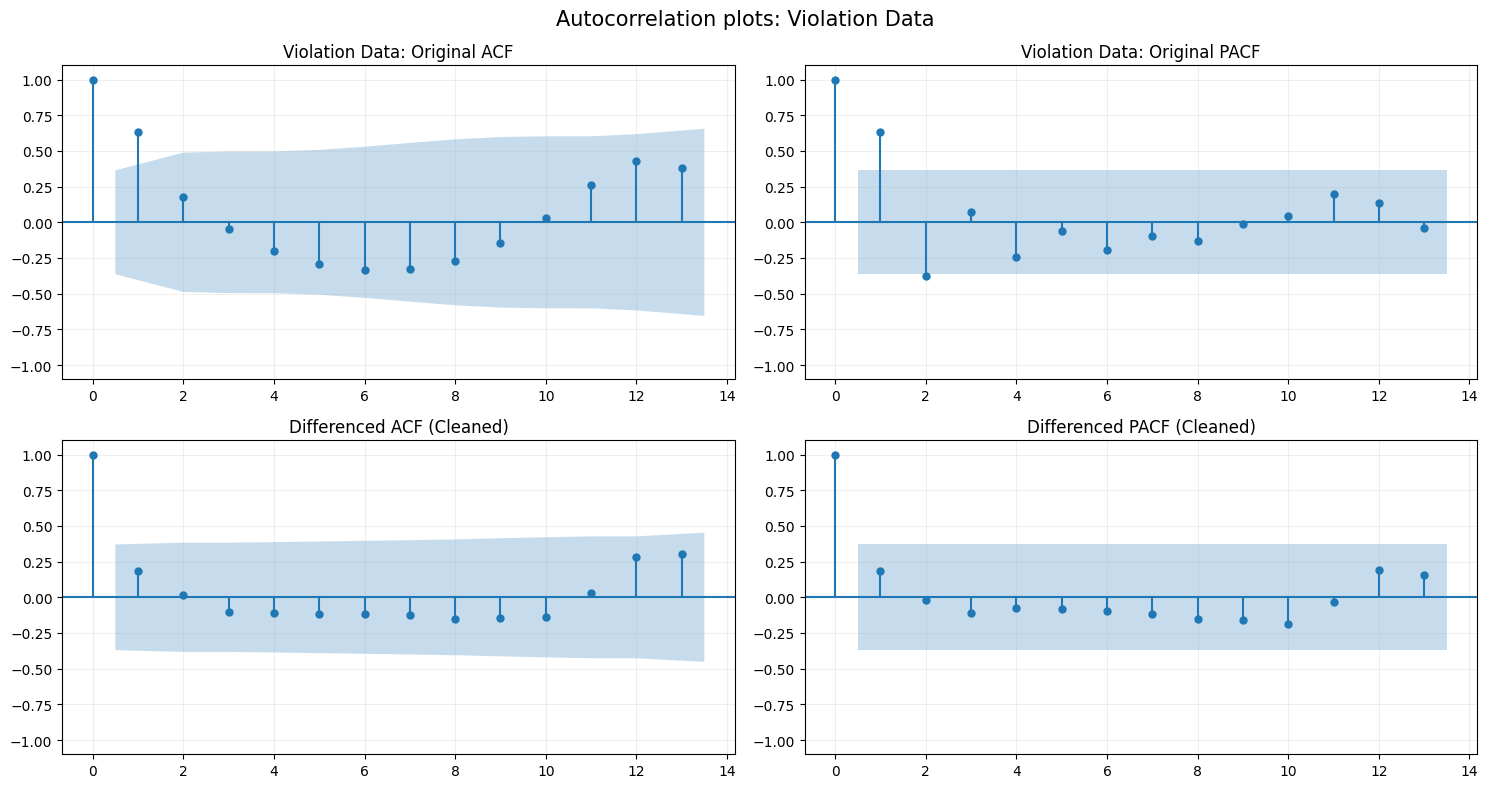


Compliance Lag Analysis:
original: ADF p: 0.03436125922130114 KPSS p: 0.1 Result: Stationary
detrended: ADF p: 0.17706254609839434 KPSS p: 0.1 Result: Ambiguous
deseasonal: ADF p: 1.0 KPSS p: 0.0283241287720358 Result: Non-Stationary
differenced: ADF p: 0.0007019427508420996 KPSS p: 0.1 Result: Stationary


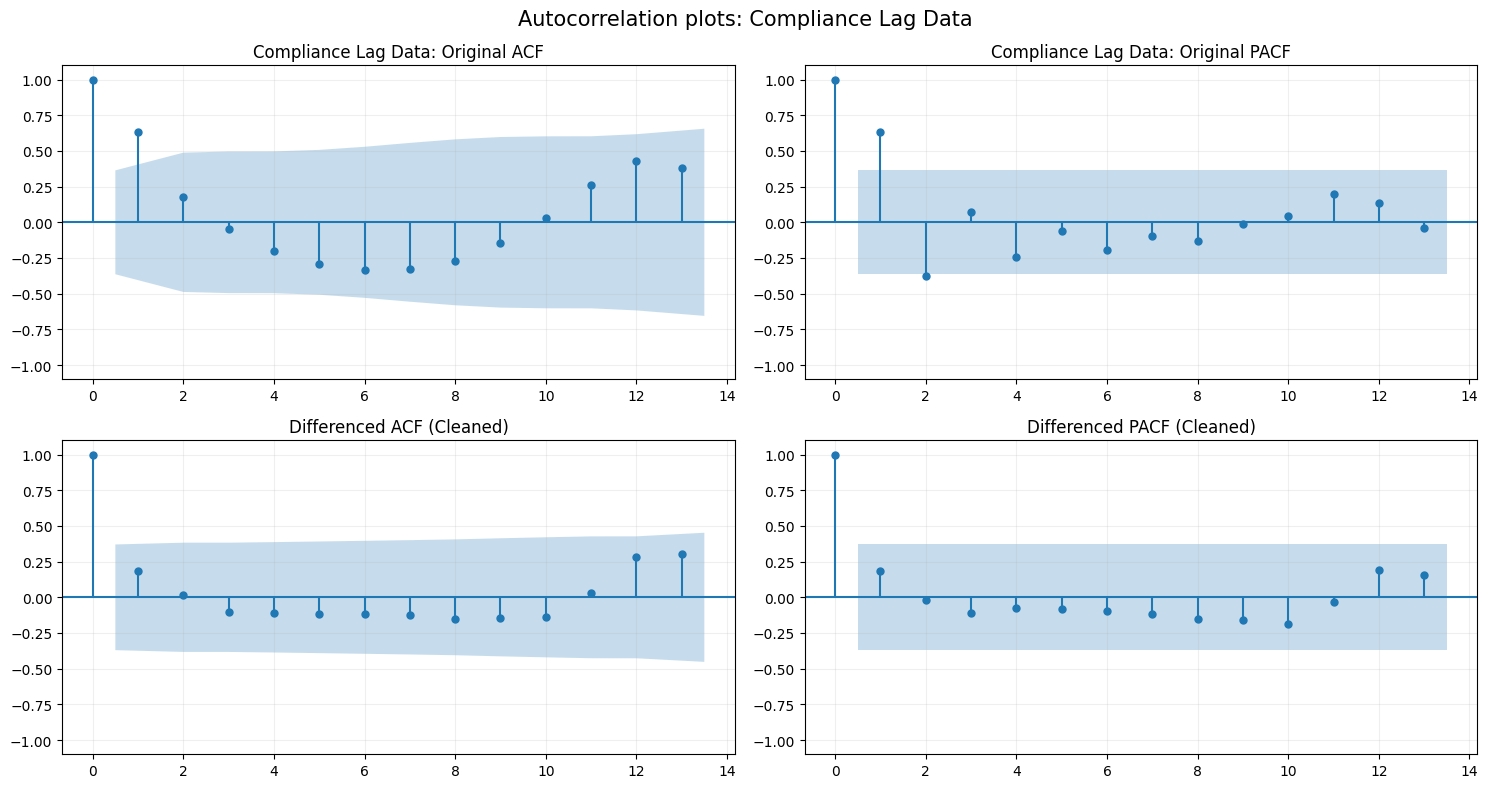

In [ ]:
#Stationarity Analysis for the two TSs
#ADF and KPSS agree on stationarity information for both the TS as-is and the Differenced TS. 
#Thus, both Violation and Compliance Lag are considered stationary
#Deseasonalised data is non-stationary, which means that seasonal behaviour is necessary for maintaining stationarity
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    print("Violation Analysis:")
    for label, data in viol_info.items():
        if isinstance(data, pd.Series):
            stationarity(data, label)
    plot_autocorrelation(viol_info['original'], 'Violation Data')

    print("\nCompliance Lag Analysis:")
    for label, data in lag_info.items():
        if isinstance(data, pd.Series):
            stationarity(data, label)
    plot_autocorrelation(viol_info['original'], 'Compliance Lag Data')

Note: The raw data is incredibly discontinous, with the vast majority of reports happening in either Jan or Feb, which indicates that the spikes at 1 and 12 months is an artefact of this, and not reflective of any on-ground data. The data should then not be regarded as seasonal.